# Trust Index Construction

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import shap

In [2]:
df = pd.read_csv('data/trust_index.csv')
df.head()

,Perceived of Accuracy,Sign Used
0,80.0,Wn-3
1,80.0,Wn-4
2,100.0,Wn-3
3,100.0,Wn-8
4,100.0,Wn-11


## Sensitivity Analysis

Exhaustive parameter/weight search to find the most stable combination parameter by rank

In [4]:
from itertools import product

def calculate_stability(df_input, acc_range, thres_range, top_n=3):
    stats = df_input.groupby('Sign Used').agg(
        Mean_Acc=('Perceived of Accuracy', 'mean'),
        Utilization=('Sign Used', 'count')
    ).reset_index()

    def norm(s): return (s - s.min()) / (s.max() - s.min()) if s.max() != s.min() else 0
    stats['Norm_Acc'] = norm(stats['Mean_Acc'])
    stats['Norm_Util'] = norm(stats['Utilization'])

    stability_results = []

    for w_acc_int, thres in product(acc_range, thres_range):
        w_acc = w_acc_int / 100.0
        w_util = 1.0 - w_acc
        
        # Apply Threshold
        temp_df = stats[stats['Utilization'] >= thres].copy()
        if temp_df.empty: continue
            
        # Calculate Index
        temp_df['TI'] = (w_acc * temp_df['Norm_Acc']) + (w_util * temp_df['Norm_Util'])
        
        # Get Top N Identity
        top_signs = tuple(temp_df.sort_values('TI', ascending=False).head(top_n)['Sign Used'].tolist())
        
        stability_results.append({
            'Identity': top_signs,
            'W_Acc': w_acc_int,
            'W_Util': 100 - w_acc_int,
            'Threshold': thres
        })

    return pd.DataFrame(stability_results), stats

# Range: Acc Weight 50-95%, Threshold 5-30 utilization
acc_range = range(50, 96, 1)
thres_range = range(5, 31, 1)

raw_stability, global_stats = calculate_stability(df, acc_range, thres_range)

stability_summary = raw_stability.groupby('Identity').agg(
    Count=('Identity', 'count'),
    Min_Acc=('W_Acc', 'min'), Max_Acc=('W_Acc', 'max'),
    Min_Thres=('Threshold', 'min'), Max_Thres=('Threshold', 'max')
).sort_values('Count', ascending=False)

print("--- Ranking Stability Zone ---")
print(stability_summary.head(5))

--- Ranking Stability Zone ---
                      Count  Min_Acc  Max_Acc  Min_Thres  Max_Thres
Identity                                                           
(Wn-2, Wn-8, Wn-1)      338       50       62          5         30
(Wn-3, Wn-8, Wn-2)      226       67       79          5         30
(Wn-3, Wn-8, Wn-1)      202       80       95         18         30
(Wn-10, Wn-11, Wn-3)    108       84       95          9         17
(Wn-2, Wn-8, Wn-3)      104       63       66          5         30


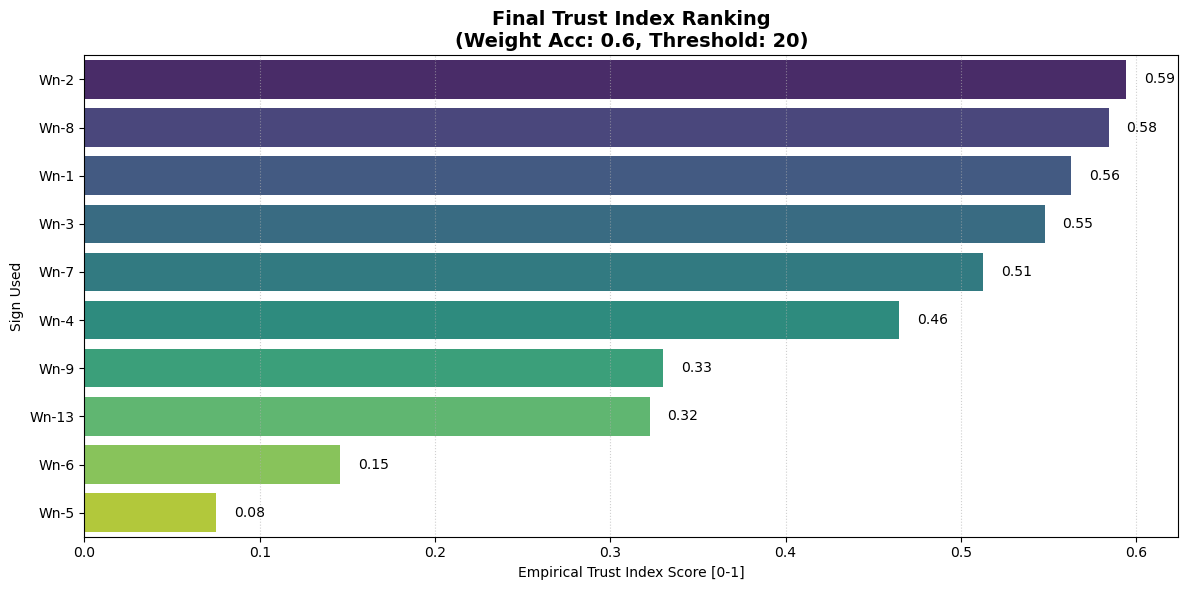

In [6]:
def plot_final_trust_index(stats, w_acc=0.75, thres=20):
    w_util = 1.0 - w_acc
    
    final_df = stats[stats['Utilization'] >= thres].copy()
    final_df['Trust_Index'] = (w_acc * final_df['Norm_Acc']) + (w_util * final_df['Norm_Util'])
    final_df = final_df.sort_values('Trust_Index', ascending=False)

    plt.figure(figsize=(12, 6))
    colors = sns.color_palette("viridis", len(final_df))
    ax = sns.barplot(data=final_df, x='Trust_Index', y='Sign Used', palette=colors, hue='Sign Used', legend=False)
    
    plt.title(f'Final Trust Index Ranking\n(Weight Acc: {w_acc}, Threshold: {thres})', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Empirical Trust Index Score [0-1]')
    plt.grid(axis='x', ls=':', alpha=0.6)
    
    # Annotate Values
    for i, v in enumerate(final_df['Trust_Index']):
        ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=10)
        
    plt.tight_layout()
    plt.show()
    return final_df

final_ranking = plot_final_trust_index(global_stats, w_acc=0.60, thres=20)

## Selecting Weights for Trust Index (Weighted Sum Model)
**Masih Menggunakan Sensitivity Analysis**. Analisis lebih lanjut menggunakan teknik pemilihan parameter seperti *Analytic Hierarchy Process* (AHP) untuk perancangan *weighted sum model* (WSM) masih perlu dipertimbangkan.

# Behavioural Modeling

In [5]:
# Load the processed data and split
df = pd.read_csv('data/processed-modeling-data.csv')

X = df.drop(columns=['Target_Action_Level'])
y = df['Target_Action_Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Load the Pre-trained Best Performing Model (XGBoost)

In [6]:
model = XGBClassifier()
model.load_model('models/xgb_behavioural.json')

## SHAP Analysis

In [16]:
import copy

CLASS_LABELS = {
    0: "Class 0: No Action (Unsafe)",
    1: "Class 1: Actionable (Safe/Proactive)"
}

def plot_filtered_shap(shap_values, X_test, target_class=0, feature_group='all', top_n=5, plot_type='beeswarm'):
    label_text = CLASS_LABELS.get(target_class, f"Class {target_class}")
    
    # 1. Handle SHAP Explanation Object & Target Class Negation
    shap_obj = copy.deepcopy(shap_values)
    if hasattr(shap_obj, "values"):
        vals = shap_obj.values
        if len(vals.shape) == 3: 
            vals = vals[:, :, target_class]
        elif target_class == 0: 
            vals = -vals
    else:
        vals = shap_obj

    # 2. Feature Group Filtering Logic
    all_cols = X_test.columns.tolist()
    if feature_group == 'wn':
        selected_cols = [c for c in all_cols if c.startswith('Wn')] 
    elif feature_group == 'demographic':
        selected_cols = [c for c in all_cols if not c.startswith('Wn')]
    else:
        selected_cols = all_cols

    # 3. Identify Top N Features within the group
    col_indices = [all_cols.index(c) for c in selected_cols]
    relevant_vals = vals[:, col_indices]
    mean_abs_shap = np.abs(relevant_vals).mean(0)
    
    top_rel_indices = np.argsort(mean_abs_shap)[-top_n:]
    final_col_indices = [col_indices[i] for i in top_rel_indices]
    final_cols = [all_cols[i] for i in final_col_indices]

    # 4. Slicing Data for Plotting
    display_X = X_test[final_cols]
    if hasattr(shap_obj, "values"):
        display_shap = vals[:, final_col_indices]
    else:
        display_shap = vals[:, final_col_indices]

    # 5. Rendering Plot
    plt.figure(figsize=(10, 6))
    if plot_type == 'bar':
        shap.summary_plot(display_shap, display_X, plot_type="bar", show=False, color="#34a872")
        plt.xlabel("Mean |SHAP Value| (Impact Magnitude)")
    else:
        shap.summary_plot(display_shap, display_X, show=False)
        plt.xlabel("SHAP Value (Impact on Model Output)")

    plt.title(f"Top {top_n} {feature_group.upper()} Features\nTarget: {label_text}", 
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [17]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

## Visualizing demographic feature for class prediction 'No Action (0)'

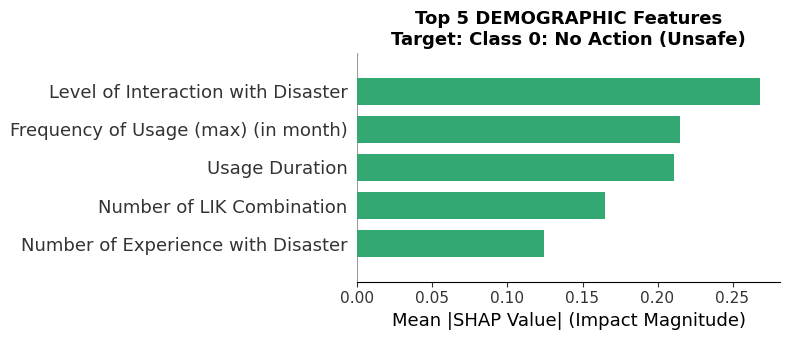

In [18]:
plot_filtered_shap(shap_values, X_test, target_class=0, feature_group='demographic', top_n=5, plot_type='bar')

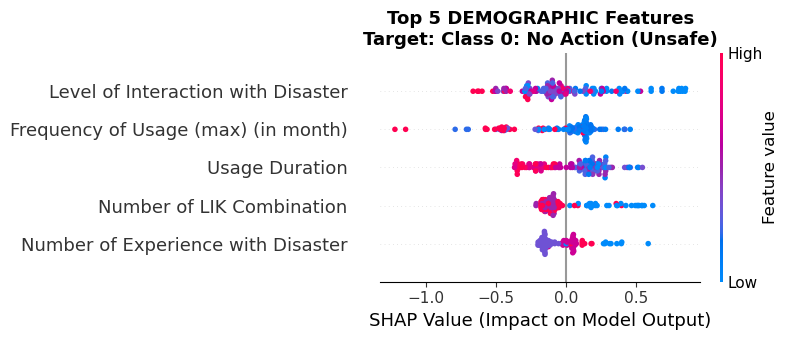

In [19]:
plot_filtered_shap(shap_values, X_test, target_class=0, feature_group='demographic', top_n=5)

Ditemukan beberapa fitur demografis yang memiliki pengaruh paling tinggi untuk model memprediksi kelas 0. Fitur-fitur ini menunjukan patter paling kuat pada bagaimana model menangkap pola data kelas 0. 
Pengaruh setiap fitur dapat dilihat pada beeswarm plot. Positive SHAP value menunjukan bahwa fitur mendorong model untuk memprediksi kelas 0, begitupun sebaliknya. 
Skala warna feature value menggambarkan nilai mentah data.

# Threshold Analysis

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

def calculate_tipping_point(shap_values, X_df, feature_name, target_class=0):
    """
    Fungsi Modular: Mengekstrak Tipping Point menggunakan Regression Tree.
    """
    # 1. Ekstraksi Nilai SHAP (Handle Explanation object, List, atau Array)
    feat_idx = X_df.columns.get_loc(feature_name)
    
    if hasattr(shap_values, "values"): # Handle SHAP Explanation
        vals = shap_values.values
        y_shap = vals[:, feat_idx, target_class] if len(vals.shape) == 3 else vals[:, feat_idx]
        if len(vals.shape) == 2 and target_class == 0: y_shap = -y_shap
    elif isinstance(shap_values, list): # Handle List
        y_shap = shap_values[target_class][:, feat_idx]
    else:
        y_shap = shap_values[:, feat_idx]

    X_vals = X_df[feature_name].values.reshape(-1, 1)

    # 2. Fit Regression Tree (Max Depth 1 untuk mencari Split Point tunggal)
    tree = DecisionTreeRegressor(max_depth=1, random_state=42).fit(X_vals, y_shap)
    threshold = tree.tree_.threshold[0]
    
    # 3. Hitung Statistik Cabang
    mask = X_vals.flatten() <= threshold
    return {
        "feature": feature_name,
        "threshold": threshold,
        "mean_low": y_shap[mask].mean(),
        "mean_high": y_shap[~mask].mean(),
        "X": X_vals, "y": y_shap
    }

def plot_tipping_point(results, target_class=0):
    """
    Fungsi Modular: Visualisasi Estetik untuk Publikasi Ilmiah.
    """
    plt.figure(figsize=(9, 5.5), dpi=100)
    X, y = results['X'], results['y']
    
    # Scatter plot dengan gradasi warna
    plt.scatter(X, y, alpha=0.4, c=y, cmap='coolwarm', edgecolors='none', s=45)
    
    # Garis Threshold (Tipping Point)
    plt.axvline(results['threshold'], color='#c0392b', ls='--', lw=2, 
                label=f"Tipping Point: {results['threshold']:.2f}")
    
    # Garis Rata-rata Impact per wilayah
    plt.hlines(results['mean_low'], xmin=X.min(), xmax=results['threshold'], 
               color='#2c3e50', lw=3.5, label=f"Mean (Low): {results['mean_low']:.3f}")
    plt.hlines(results['mean_high'], xmin=results['threshold'], xmax=X.max(), 
               color='#2980b9', lw=3.5, label=f"Mean (High): {results['mean_high']:.3f}")

    # Labeling & Aesthetics
    class_label = "No Action (Unsafe)" if target_class == 0 else "Actionable (Safe)"
    plt.title(f"Tipping Point Analysis: {results['feature']}\nTarget: {class_label}", 
              fontsize=12, fontweight='bold', loc='left')
    plt.xlabel(f"Input Value: {results['feature']}", fontsize=10)
    plt.ylabel("SHAP Impact Score", fontsize=10)
    plt.axhline(0, color='black', lw=0.8, alpha=0.3)
    plt.legend(frameon=True, fontsize=9, loc='best')
    plt.grid(axis='y', ls=':', alpha=0.3)
    plt.tight_layout()
    plt.show()

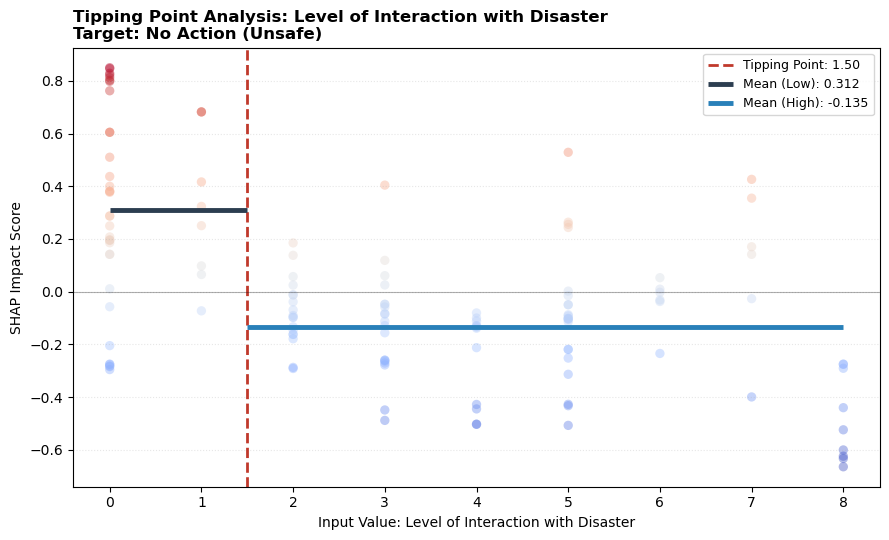

LOGIC RULE: If Level of Interaction with Disaster > 1.50, Impact on Class 0 shifts by 0.4468


In [24]:
tp_res = calculate_tipping_point(shap_values, X_test, 'Level of Interaction with Disaster', target_class=0)
plot_tipping_point(tp_res, target_class=0)

print(f"LOGIC RULE: If {tp_res['feature']} > {tp_res['threshold']:.2f}, "
      f"Impact on Class 0 shifts by {abs(tp_res['mean_high'] - tp_res['mean_low']):.4f}")

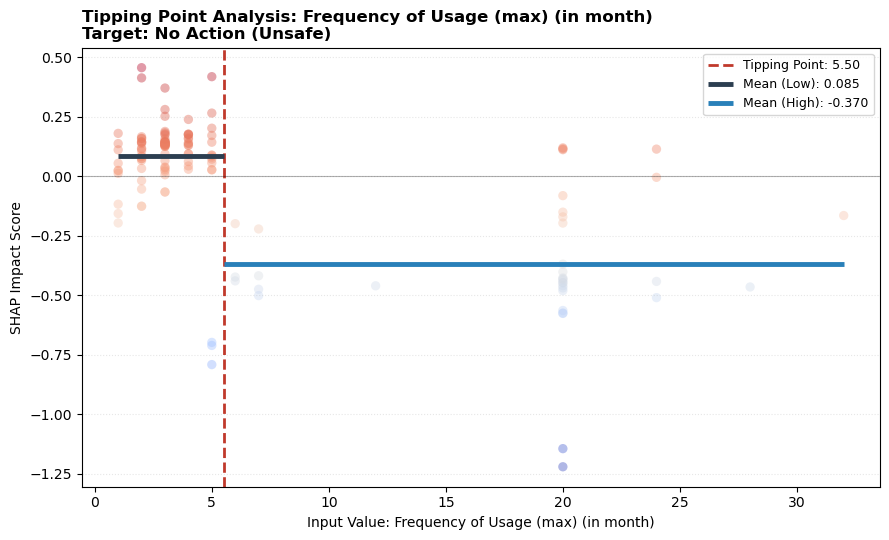

LOGIC RULE: If Frequency of Usage (max) (in month) > 5.50, Impact on Class 0 shifts by 0.4550


In [25]:
tp_res = calculate_tipping_point(shap_values, X_test, 'Frequency of Usage (max) (in month)', target_class=0)
plot_tipping_point(tp_res, target_class=0)

print(f"LOGIC RULE: If {tp_res['feature']} > {tp_res['threshold']:.2f}, "
      f"Impact on Class 0 shifts by {abs(tp_res['mean_high'] - tp_res['mean_low']):.4f}")

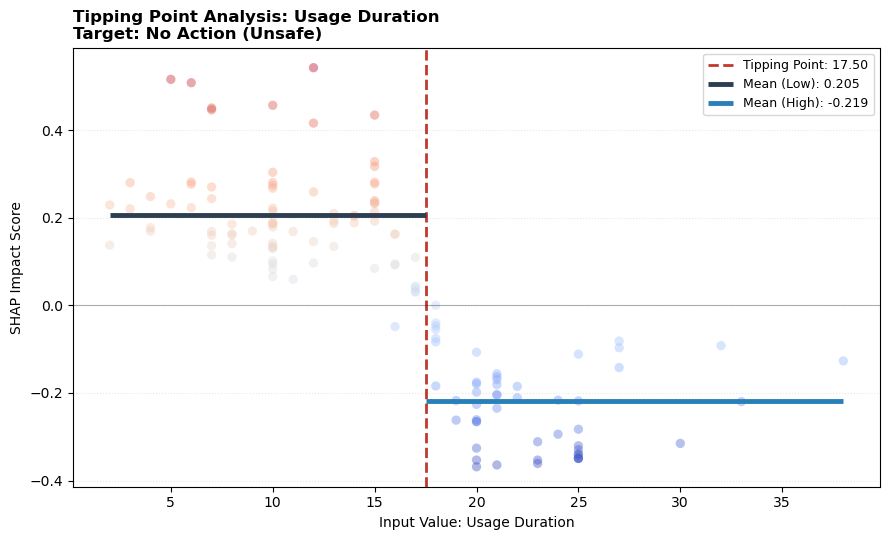

LOGIC RULE: If Usage Duration > 17.50, Impact on Class 0 shifts by 0.4241


In [26]:
tp_res = calculate_tipping_point(shap_values, X_test, 'Usage Duration', target_class=0)
plot_tipping_point(tp_res, target_class=0)

print(f"LOGIC RULE: If {tp_res['feature']} > {tp_res['threshold']:.2f}, "
      f"Impact on Class 0 shifts by {abs(tp_res['mean_high'] - tp_res['mean_low']):.4f}")

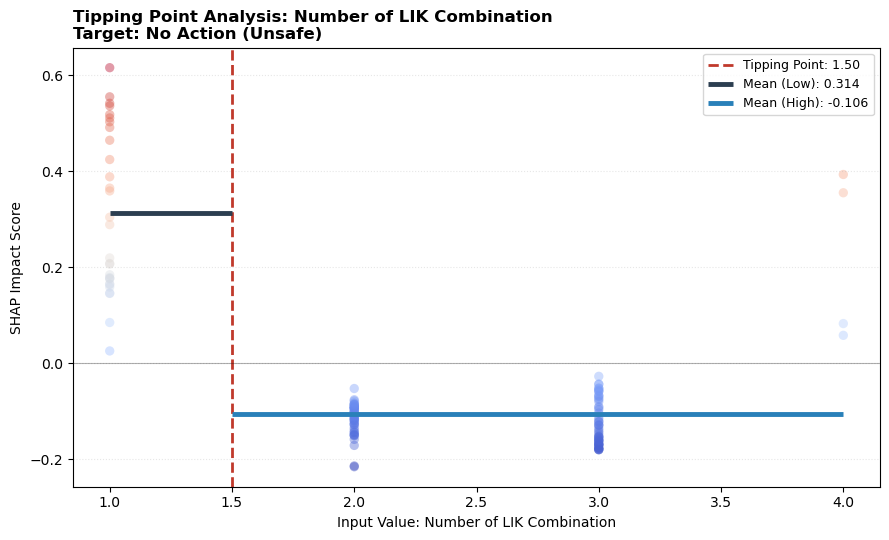

LOGIC RULE: If Number of LIK Combination > 1.50, Impact on Class 0 shifts by 0.4207


In [27]:
tp_res = calculate_tipping_point(shap_values, X_test, 'Number of LIK Combination', target_class=0)
plot_tipping_point(tp_res, target_class=0)

print(f"LOGIC RULE: If {tp_res['feature']} > {tp_res['threshold']:.2f}, "
      f"Impact on Class 0 shifts by {abs(tp_res['mean_high'] - tp_res['mean_low']):.4f}")

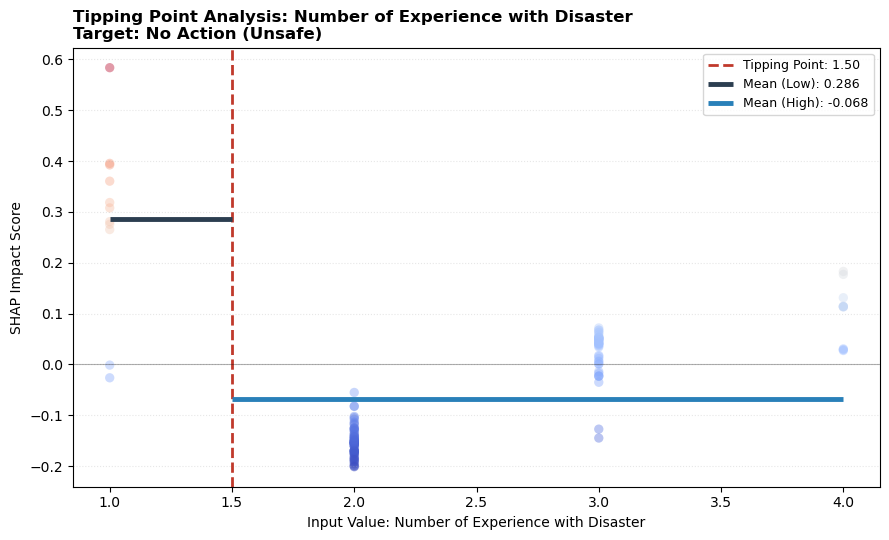

LOGIC RULE: If Number of Experience with Disaster > 1.50, Impact on Class 0 shifts by 0.3544


In [52]:
tp_res = calculate_tipping_point(shap_values, X_test, 'Number of Experience with Disaster', target_class=0)
plot_tipping_point(tp_res, target_class=0)

print(f"LOGIC RULE: If {tp_res['feature']} > {tp_res['threshold']:.2f}, "
      f"Impact on Class 0 shifts by {abs(tp_res['mean_high'] - tp_res['mean_low']):.4f}")

## Rules from SHAP analysis

- Level of Interaction with Disaster < 1.50: Mendorong model untuk predict class 0

- Frequency of Usage < 5.50: Mendorong model untuk predict class 0

- Usage duration < 17.50: mendorong model untuk predict class 0

- Number of LIK Combination < 1.50: mendorong model untuk predict class 0

- Number of Experience with disaster < 1.50: mendorong model untuk predict class 0

Seluruh rule yang ditemukan dari feature SHAP analysis ini selaras dengan narasi bahwa pengalaman yang rendah dalam bencana/pengunaan tanda alam merupakan kecenderungan seseorang untuk bersikap abai/no action ketika tanda alam bencana muncul